# ASHRAE GEPIII – Exploratory Data Analysis


In [4]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import build

sns.set_theme(style="whitegrid")

In [5]:
df = build("train")
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 19867540 entries, 0 to 19867539
Data columns (total 23 columns):
 #   Column              Dtype         
---  ------              -----         
 0   building_id         int16         
 1   meter               int8          
 2   timestamp           datetime64[us]
 3   meter_reading       float64       
 4   site_id             int8          
 5   primary_use         category      
 6   square_feet         float32       
 7   year_built          float32       
 8   floor_count         float32       
 9   air_temperature     float32       
 10  cloud_coverage      float32       
 11  dew_temperature     float32       
 12  precip_depth_1_hr   float32       
 13  sea_level_pressure  float32       
 14  wind_direction      float32       
 15  wind_speed          float32       
 16  building_age        float32       
 17  hour                int8          
 18  weekday             int8          
 19  month               int8          
 20  is_weekend 

## Target distribution


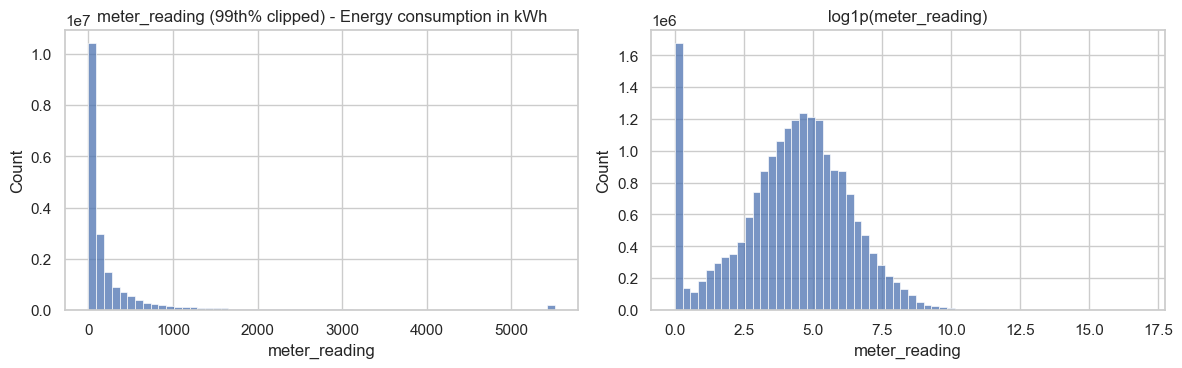

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["meter_reading"].clip(upper=df["meter_reading"].quantile(0.99)), bins=60, ax=ax[0])
ax[0].set_title("meter_reading (99th% clipped) - Energy consumption in kWh")
sns.histplot(np.log1p(df["meter_reading"]), bins=60, ax=ax[1])
ax[1].set_title("log1p(meter_reading)")
plt.tight_layout()

## Readings by meter type and primary use


Text(0.5, 0, '')

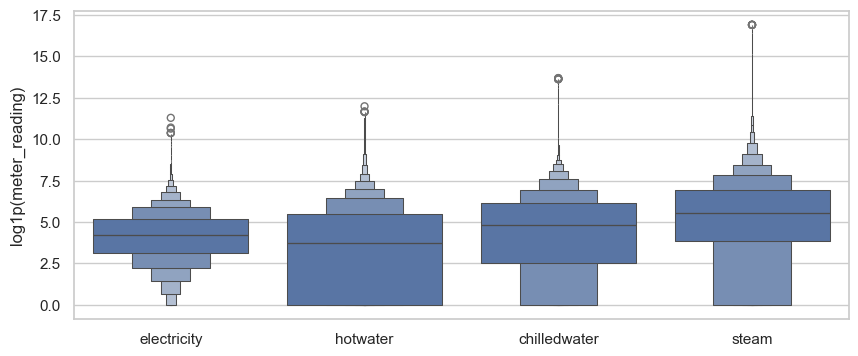

In [16]:
meter_map = {0: "electricity", 1: "chilledwater", 2: "steam", 3: "hotwater"}
plt.figure(figsize=(10, 4))
sns.boxenplot(x=df["meter"].map(meter_map), y=np.log1p(df["meter_reading"]))
plt.ylabel("log1p(meter_reading)")
plt.xlabel("Meter type")

Text(0, 0.5, 'Primary Use')

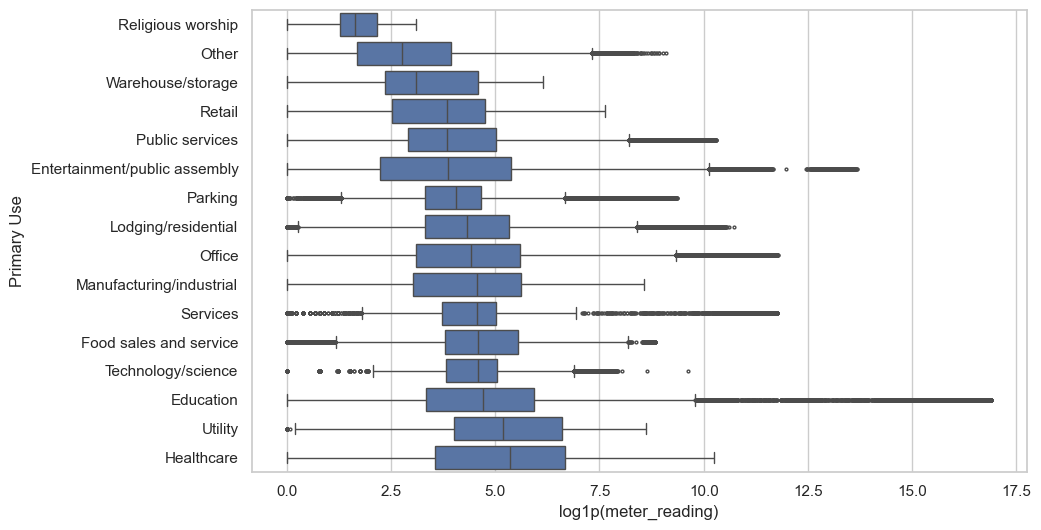

In [24]:
plt.figure(figsize=(10, 6))
order = df.groupby("primary_use")["meter_reading"].median().sort_values().index
sns.boxplot(data=df, y="primary_use", x=np.log1p(df["meter_reading"]), order=order, fliersize=2.5)
plt.xlabel("log1p(meter_reading)")
plt.ylabel("Primary Use")

## Hourly seasonality


Text(0, 0.5, 'Median Energy Consumption (kWh)')

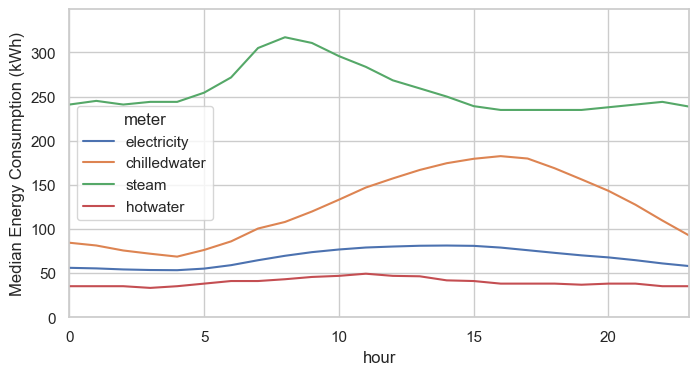

In [31]:
hourly = df.groupby(["meter", "hour"])["meter_reading"].median().reset_index()
hourly["meter"] = hourly["meter"].map(meter_map)
plt.figure(figsize=(8, 4))
sns.lineplot(data=hourly, x="hour", y="meter_reading", hue="meter")
plt.ylabel("median meter_reading")
plt.xlim(0, 23)
plt.ylim(0, hourly["meter_reading"].max() * 1.1)
plt.ylabel("Median Energy Consumption (kWh)")

## Weather correlations


In [37]:
df

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,...,sea_level_pressure,wind_direction,wind_speed,building_age,hour,weekday,month,is_weekend,hdh,cdh
0,105,0,2016-01-01 00:00:00,23.3036,1,Education,50623.0,NaN,5.0,3.8,...,1020.900024,240.0,3.1,NaN,0,4,1,0,14.200000,0.0
1,106,0,2016-01-01 00:00:00,0.3746,1,Education,5374.0,NaN,4.0,3.8,...,1020.900024,240.0,3.1,NaN,0,4,1,0,14.200000,0.0
2,106,3,2016-01-01 00:00:00,0.0000,1,Education,5374.0,NaN,4.0,3.8,...,1020.900024,240.0,3.1,NaN,0,4,1,0,14.200000,0.0
3,107,0,2016-01-01 00:00:00,175.1840,1,Education,97532.0,2005.0,10.0,3.8,...,1020.900024,240.0,3.1,11.0,0,4,1,0,14.200000,0.0
4,108,0,2016-01-01 00:00:00,91.2653,1,Education,81580.0,1913.0,5.0,3.8,...,1020.900024,240.0,3.1,103.0,0,4,1,0,14.200000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19867535,1444,0,2016-12-31 23:00:00,8.7500,15,Entertainment/public assembly,19619.0,1914.0,NaN,1.7,...,1008.500000,180.0,8.8,102.0,23,5,12,1,16.299999,0.0
19867536,1445,0,2016-12-31 23:00:00,4.8250,15,Education,4298.0,NaN,NaN,1.7,...,1008.500000,180.0,8.8,NaN,23,5,12,1,16.299999,0.0
19867537,1446,0,2016-12-31 23:00:00,0.0000,15,Entertainment/public assembly,11265.0,1997.0,NaN,1.7,...,1008.500000,180.0,8.8,19.0,23,5,12,1,16.299999,0.0
19867538,1447,0,2016-12-31 23:00:00,159.5750,15,Lodging/residential,29775.0,2001.0,NaN,1.7,...,1008.500000,180.0,8.8,15.0,23,5,12,1,16.299999,0.0


<Axes: >

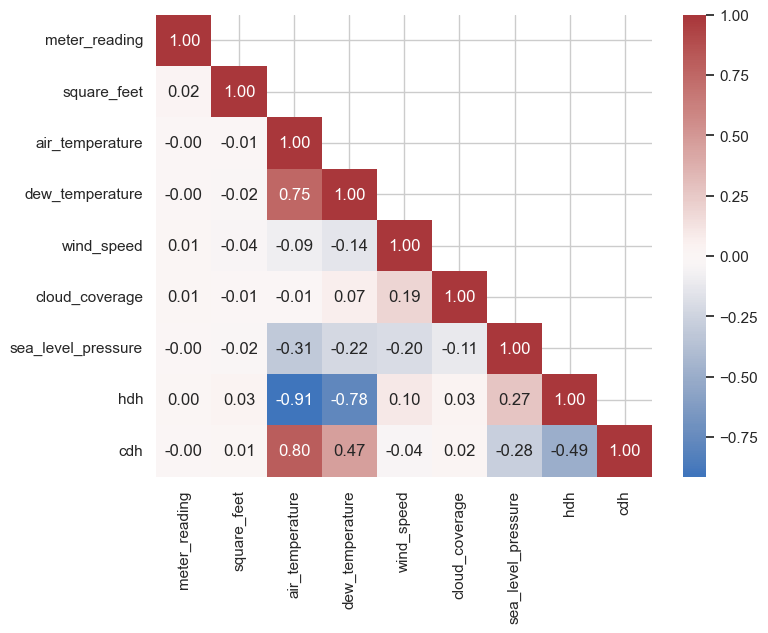

In [36]:
# keep only one symmetric half (lower triangle)
corr = df[num].corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(8, 6))
sns.heatmap(df[num].corr(numeric_only=True), mask=mask, annot=True, fmt=".2f", cmap="vlag", center=0)

## Missingness


In [11]:
miss = df.isna().mean().sort_values(ascending=False)
miss[miss > 0]

floor_count           0.823484
building_age          0.610425
year_built            0.610425
dew_temperature       0.004555
cloud_coverage        0.004555
hdh                   0.004555
wind_speed            0.004555
wind_direction        0.004555
sea_level_pressure    0.004555
precip_depth_1_hr     0.004555
cdh                   0.004555
air_temperature       0.004555
dtype: float64